## Titanic DtaAnalysis

# 1. load and understand the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [3]:
df.head(10)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
5,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,1
6,1,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,0,13502,77.9583,D7,S,1
7,1,"Andrews, Mr. Thomas Jr",male,39.0000,0,0,112050,0.0000,A36,S,0
8,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,2,0,11769,51.4792,C101,S,1
9,1,"Artagaveytia, Mr. Ramon",male,71.0000,0,0,PC 17609,49.5042,NaN,C,0


In [4]:
df.tail(10)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
1299,3,"Yasbeck, Mr. Antoni",male,27.0,1,0,2659,14.4542,NaN,C,0
1300,3,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.0,1,0,2659,14.4542,NaN,C,1
1301,3,"Youseff, Mr. Gerious",male,45.5,0,0,2628,7.2250,NaN,C,0
1302,3,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,0
1303,3,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C,0
1304,3,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,0
1308,3,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,0


In [5]:
df.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'survived'],
      dtype='str')

sibsp --> Siblings and spouse count
parch --> parents and children count
embarked --> port name
fare --> ticket price or amount
pclass --> passenger class

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   str    
 2   sex       1309 non-null   str    
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    str    
 9   embarked  1307 non-null   str    
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 112.6 KB


# Missing Data
age,fare,cabin,embarked

In [7]:
for col in ['age','cabin','fare','embarked']:
    col1 = df[col].isnull().sum()
    print(f"{col} : {col1}")

age : 263
cabin : 1014
fare : 1
embarked : 2




# 2. clean the dataset

1. check for duplicates and remove them

2. check for missing values and handle them/remove them

3. check for invalid datatypes and handle them

4. remove any unwanted columns


In [8]:
df.duplicated().any() # no duplicate


np.False_

In [9]:
age_mean = df['age'].mean()
age_mean

np.float64(29.8811345124283)

In [10]:
df['age']=df['age'].fillna(age_mean)
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.000000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.916700,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.000000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.000000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.500000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,29.881135,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.500000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.000000,0,0,2670,7.2250,NaN,C,0


In [11]:
fare_mean = df['fare'].mean()
df['fare']=df['fare'].fillna(fare_mean)

In [12]:
embarked_mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(embarked_mode)


In [13]:
df=df.dropna(axis=1) # check for columns which are having missing values and remove them
# axis = 0 (rows), axis = 1 (columns)
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.000000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.916700,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.000000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.000000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000000,1,2,113781,151.5500,S,0
...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.500000,1,0,2665,14.4542,C,0
1305,3,"Zabour, Miss. Thamine",female,29.881135,1,0,2665,14.4542,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.500000,0,0,2656,7.2250,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.000000,0,0,2670,7.2250,C,0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   str    
 2   sex       1309 non-null   str    
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   str    
 9   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 102.4 KB


# 3. Transfor the dataset (Data Manipulation / Data Transformation)

In [15]:
df['famliy_count']=df['sibsp']+df['parch']
# df.drop(['sibsp','parch'])
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count
0,1,"Allen, Miss. Elisabeth Walton",female,29.000000,0,0,24160,211.3375,S,1,0
1,1,"Allison, Master. Hudson Trevor",male,0.916700,1,2,113781,151.5500,S,1,3
2,1,"Allison, Miss. Helen Loraine",female,2.000000,1,2,113781,151.5500,S,0,3
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.000000,1,2,113781,151.5500,S,0,3
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000000,1,2,113781,151.5500,S,0,3
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.500000,1,0,2665,14.4542,C,0,1
1305,3,"Zabour, Miss. Thamine",female,29.881135,1,0,2665,14.4542,C,0,1
1306,3,"Zakarian, Mr. Mapriededer",male,26.500000,0,0,2656,7.2250,C,0,0
1307,3,"Zakarian, Mr. Ortin",male,27.000000,0,0,2670,7.2250,C,0,0


In [16]:
df['ticket'].unique()

<StringArray>
[     '24160',     '113781',      '19952',      '13502',     '112050',
      '11769',   'PC 17609',   'PC 17757',   'PC 17477',      '19877',
 ...
     '315154', 'A/4. 34244',     '345771',       '2659',       '2628',
       '2647',       '2665',       '2656',       '2670',     '315082']
Length: 929, dtype: str

In [17]:
df = df.sort_values(by='ticket')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count
67,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,S,1,0
245,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.500,S,1,0
195,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.500,S,1,0
289,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,S,1,2
291,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,S,1,2
...,...,...,...,...,...,...,...,...,...,...,...
63,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.175,S,1,1
62,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.175,S,0,1
433,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.500,S,0,0
81,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.000,S,0,2


In [18]:
df = df.reset_index(drop=True)
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count
0,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,S,1,0
1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.500,S,1,0
2,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.500,S,1,0
3,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,S,1,2
4,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,S,1,2
...,...,...,...,...,...,...,...,...,...,...,...
1304,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.175,S,1,1
1305,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.175,S,0,1
1306,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.500,S,0,0
1307,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.000,S,0,2


In [19]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [20]:
df['embarked'] = df['embarked'].replace({'S':'Southampton','C' : 'Cherbourg', 'Q' : 'Queenstown'})
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count
0,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,Southampton,1,0
1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.500,Southampton,1,0
2,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.500,Southampton,1,0
3,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,Southampton,1,2
4,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,Southampton,1,2
...,...,...,...,...,...,...,...,...,...,...,...
1304,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.175,Southampton,1,1
1305,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.175,Southampton,0,1
1306,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.500,Southampton,0,0
1307,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.000,Southampton,0,2


In [21]:
df['fare']=df['fare'].round(1)
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count
0,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5,Southampton,1,0
1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,Southampton,1,0
2,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5,Southampton,1,0
3,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6,Southampton,1,2
4,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6,Southampton,1,2
...,...,...,...,...,...,...,...,...,...,...,...
1304,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1
1305,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1
1306,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.5,Southampton,0,0
1307,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2


In [22]:
df[['lname','Temp']]=df['name'].str.split(',' ,expand=True)
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count,lname,Temp
0,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss. Gladys
1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess. of (Lucy Noel Martha Dyer-Edwards)
2,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss. Roberta
3,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss. Ruth
4,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs. Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs. Herbert Fuller (Carrie Constance Toogood)
1305,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr. Herbert Fuller
1306,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr. Walter
1307,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt. Edward Gifford


In [23]:
df[['title','fname']] = df['Temp'].str.split('.',n=1,expand=True )
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count,lname,Temp,title,fname
0,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss. Gladys,Miss,Gladys
1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess. of (Lucy Noel Martha Dyer-Edwards),the Countess,of (Lucy Noel Martha Dyer-Edwards)
2,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss. Roberta,Miss,Roberta
3,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss. Ruth,Miss,Ruth
4,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs. Emil (Tillie Mandelbaum),Mrs,Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs. Herbert Fuller (Carrie Constance Toogood),Mrs,Herbert Fuller (Carrie Constance Toogood)
1305,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr. Herbert Fuller,Mr,Herbert Fuller
1306,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr. Walter,Mr,Walter
1307,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt. Edward Gifford,Capt,Edward Gifford


In [24]:
df['title'].str.strip()

0               Miss
1       the Countess
2               Miss
3               Miss
4                Mrs
            ...     
1304             Mrs
1305              Mr
1306              Mr
1307            Capt
1308            Miss
Name: title, Length: 1309, dtype: str

In [25]:
for col in ['title','lname','fname']:
    df[col] = df[col].str.strip()
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count,lname,Temp,title,fname
0,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss. Gladys,Miss,Gladys
1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess. of (Lucy Noel Martha Dyer-Edwards),the Countess,of (Lucy Noel Martha Dyer-Edwards)
2,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss. Roberta,Miss,Roberta
3,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss. Ruth,Miss,Ruth
4,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs. Emil (Tillie Mandelbaum),Mrs,Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs. Herbert Fuller (Carrie Constance Toogood),Mrs,Herbert Fuller (Carrie Constance Toogood)
1305,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr. Herbert Fuller,Mr,Herbert Fuller
1306,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr. Walter,Mr,Walter
1307,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt. Edward Gifford,Capt,Edward Gifford


In [26]:
df = df.drop(columns=['name','Temp'])


In [27]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count,lname,title,fname
0,1,female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss,Gladys
1,1,female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards)
2,1,female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss,Roberta
3,1,female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss,Ruth
4,1,female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs,Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood)
1305,1,male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr,Herbert Fuller
1306,2,male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr,Walter
1307,1,male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt,Edward Gifford


In [28]:
df['sex'] = df['sex'].str.title()

In [29]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count,lname,title,fname
0,1,Female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss,Gladys
1,1,Female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards)
2,1,Female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss,Roberta
3,1,Female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss,Ruth
4,1,Female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs,Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood)
1305,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr,Herbert Fuller
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr,Walter
1307,1,Male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt,Edward Gifford


In [30]:
df['ticket'].value_counts()

ticket
CA. 2343       11
1601            8
CA 2144         8
3101295         7
347077          7
               ..
W./C. 14260     1
W./C. 14263     1
W./C. 14266     1
W./C. 6609      1
W/C 14208       1
Name: count, Length: 929, dtype: int64

In [31]:
d = dict(df['ticket'].value_counts())

In [32]:
df['psg_cnt'] = df['ticket'].map(d)

In [33]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,famliy_count,lname,title,fname,psg_cnt
0,1,Female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss,Gladys,3
1,1,Female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),3
2,1,Female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss,Roberta,3
3,1,Female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss,Ruth,3
4,1,Female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs,Emil (Tillie Mandelbaum),3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),2
1305,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr,Herbert Fuller,2
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr,Walter,1
1307,1,Male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt,Edward Gifford,2


In [34]:
df = df.rename(columns={'sex' : 'gender', 'embarked' : 'port','famliy_count' : 'family_count'})

In [35]:
df

,pclass,gender,age,sibsp,parch,ticket,fare,port,survived,family_count,lname,title,fname,psg_cnt
0,1,Female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss,Gladys,3
1,1,Female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),3
2,1,Female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss,Roberta,3
3,1,Female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss,Ruth,3
4,1,Female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs,Emil (Tillie Mandelbaum),3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),2
1305,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr,Herbert Fuller,2
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr,Walter,1
1307,1,Male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt,Edward Gifford,2


In [36]:
def comp_type_func(row):
   f =  row['family_count'] #holds one value (single cell value)
   p = row['psg_cnt']   #holds one value 
   if p == 1:
      return 'solo'
   elif f == 0:
      return 'friends'
   else:
      return 'family'

In [37]:
df['companin_type'] = df.apply(comp_type_func ,axis=1)
# axis = 1 (select all columns of 1st row........nth row)

In [38]:
df

,pclass,gender,age,sibsp,parch,ticket,fare,port,survived,family_count,lname,title,fname,psg_cnt,companin_type
0,1,Female,30.0,0,0,110152,86.5,Southampton,1,0,Cherry,Miss,Gladys,3,friends
1,1,Female,33.0,0,0,110152,86.5,Southampton,1,0,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),3,friends
2,1,Female,16.0,0,0,110152,86.5,Southampton,1,0,Maioni,Miss,Roberta,3,friends
3,1,Female,18.0,0,2,110413,79.6,Southampton,1,2,Taussig,Miss,Ruth,3,family
4,1,Female,39.0,1,1,110413,79.6,Southampton,1,2,Taussig,Mrs,Emil (Tillie Mandelbaum),3,family
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.2,Southampton,1,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),2,family
1305,1,Male,46.0,1,0,W.E.P. 5734,61.2,Southampton,0,1,Chaffee,Mr,Herbert Fuller,2,family
1306,2,Male,30.0,0,0,W/C 14208,10.5,Southampton,0,0,Harris,Mr,Walter,1,solo
1307,1,Male,70.0,1,1,WE/P 5735,71.0,Southampton,0,2,Crosby,Capt,Edward Gifford,2,family


In [39]:
df.columns

Index(['pclass', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'port',
       'survived', 'family_count', 'lname', 'title', 'fname', 'psg_cnt',
       'companin_type'],
      dtype='str')

In [40]:
new_column_order = ['ticket','title','fname','lname','gender', 'age','companin_type','port','pclass','fare','survived']

In [41]:
df = df[new_column_order]

# 4 . Data Analysis

1. using pandas
2. using visuals

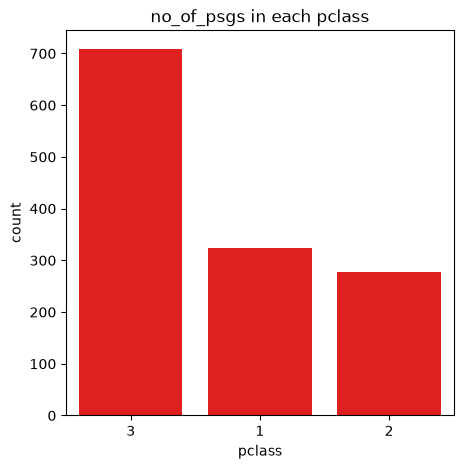

In [73]:
plt.figure(figsize=(5,5))
sns.countplot(x='pclass',data=df,color='red',order=[3,1,2])
plt.title('no_of_psgs in each pclass')
plt.show()

2. plot gender 

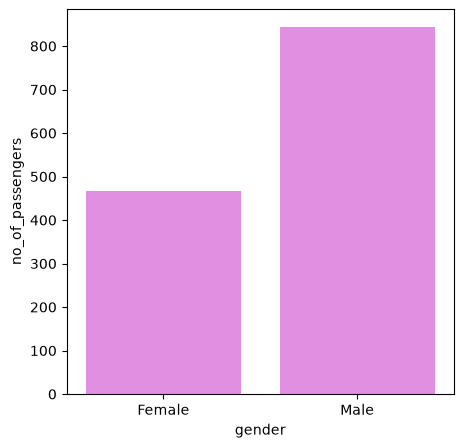

In [43]:
plt.figure(figsize=(5,5)) #(width,height)
sns.countplot(df,x='gender',color='violet')
plt.ylabel("no_of_passengers")
plt.show()

3.plot the portion/percentage pf passengers in each pclass 

In [44]:
p = df['pclass'].value_counts()
p.values

array([709, 323, 277])

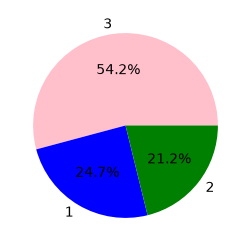

In [45]:
plt.figure(figsize=(3,3))
plt.pie(x=p.values,autopct='%.1f%%',labels=p.index,colors=['pink', 'blue','green'])
plt.show()

4. Distribution of passengers age 

In [46]:
import numpy as np

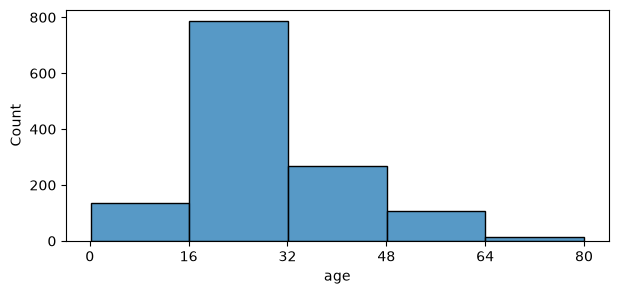

In [47]:
plt.figure(figsize=(7,3))
sns.histplot(df,x='age',bins=5)
nums = np.linspace(0,80,6)
plt.xticks(nums)
plt.show()

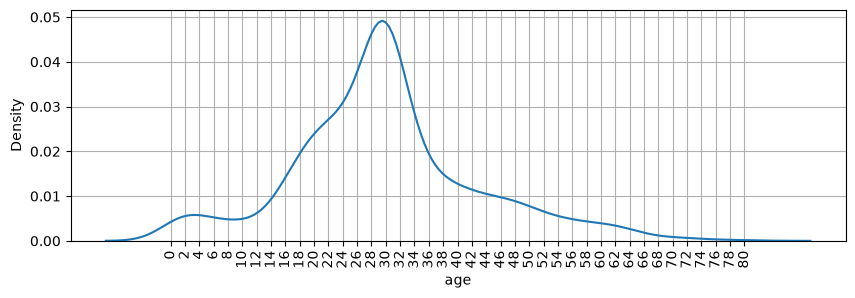

In [48]:
plt.figure(figsize=(10,3))
sns.kdeplot(df,x='age') # kernel density estimation 
plt.xticks(range(0,81,2),rotation=90)
plt.grid()
plt.show()

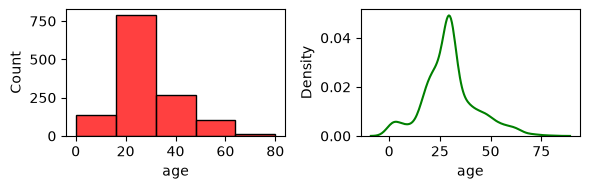

In [49]:
f,a = plt.subplots(nrows=1,ncols= 2,figsize=(6,2)) # a = axes , f = figure
sns.histplot(df,x='age',bins=5,ax= a[0],color= 'red')
sns.kdeplot(df,x='age',ax= a[1], color= 'green')
plt.tight_layout()

5. plot the total_fare for each pclass

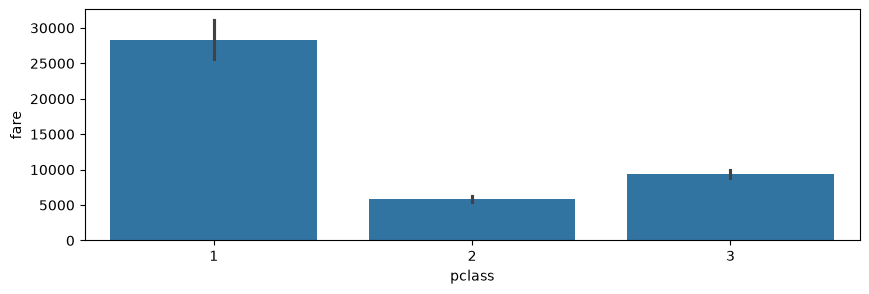

In [50]:
plt.figure(figsize=(10,3))
sns.barplot(df,x='pclass',y='fare', estimator='sum')
plt.show()

## Observation
The total fare is higher from pclass 1 followed by pclass 3 and pclass 2

6. plot gender wise total fare

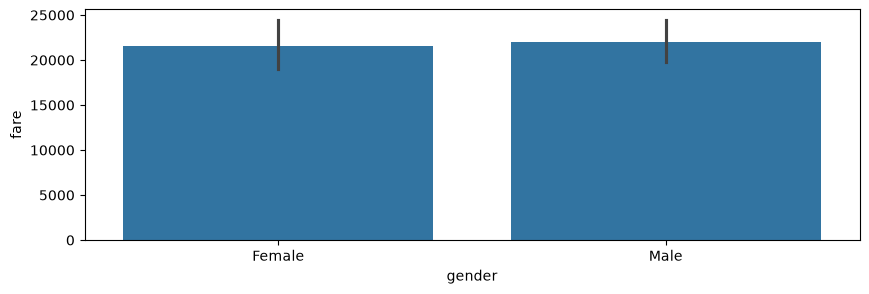

In [51]:
plt.figure(figsize=(10,3))
sns.barplot(df,x='gender',y='fare',estimator='sum')
plt.show()

## Observation 
The total fare of male and female is almost same

7. plot pclass wise number of male and female

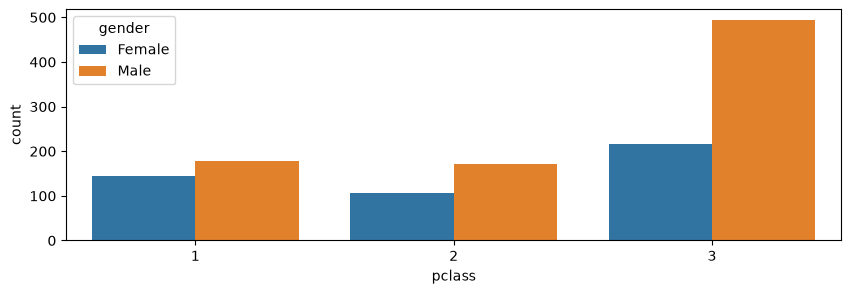

In [52]:
plt.figure(figsize=(10,3)) #(width,height)
sns.countplot(df,x='pclass',hue='gender')
plt.show()

## Observation 
1. More number of males are in all the pclass
2. Most of the males are preforing pclass 3

8. plot pclass wise total fare of male and female

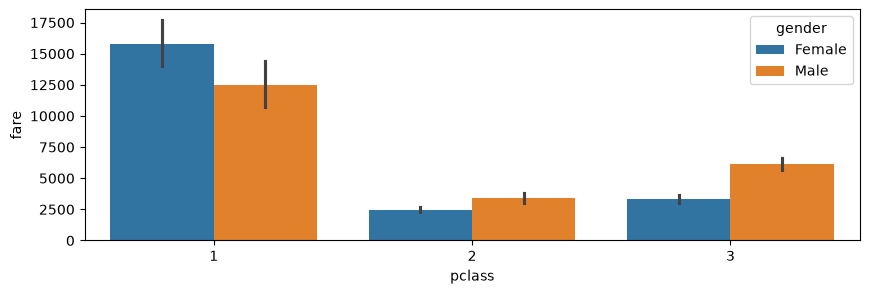

In [53]:
plt.figure(figsize=(10,3))
sns.barplot(df,x='pclass',y='fare',estimator='sum',hue='gender')
plt.show()

## Observation
1. pclass 1 male and female passengers totel fare is higher regadless of number of passengers (bez pclass fare is costly)

9.plot the relationship between age and fare

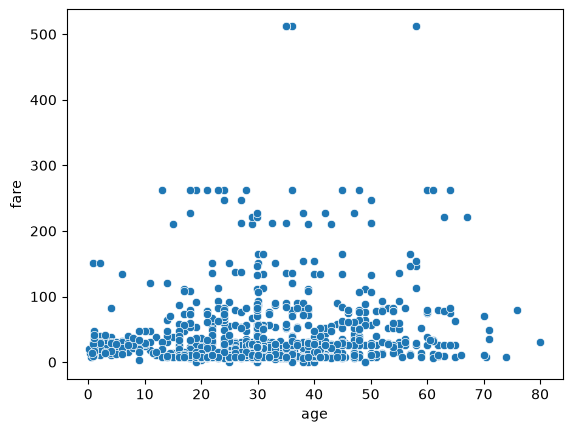

In [54]:
sns.scatterplot(df,x='age',y='fare')
plt.show()

10. get the corelation for all numarical columns 

In [55]:
c=df.corr(numeric_only= True)

<Axes: >

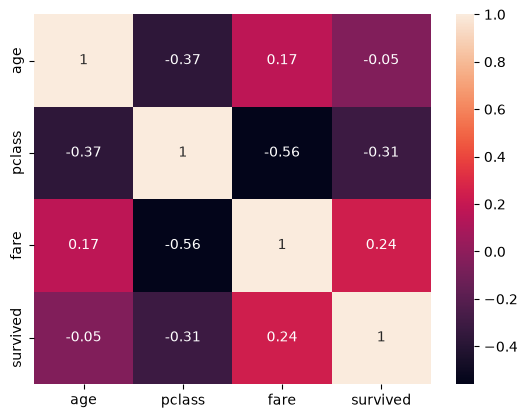

In [56]:
sns.heatmap(c,annot=True)# annot display the numbers in heatmap

- pclass has negitive 31% influence on survivel
- pclass has negitive 56% influence on fare


<Axes: xlabel='fare'>

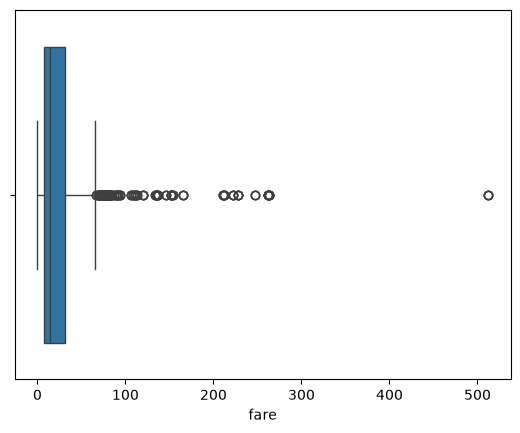

In [58]:
sns.boxplot(df,x='fare')

<Axes: xlabel='age', ylabel='gender'>

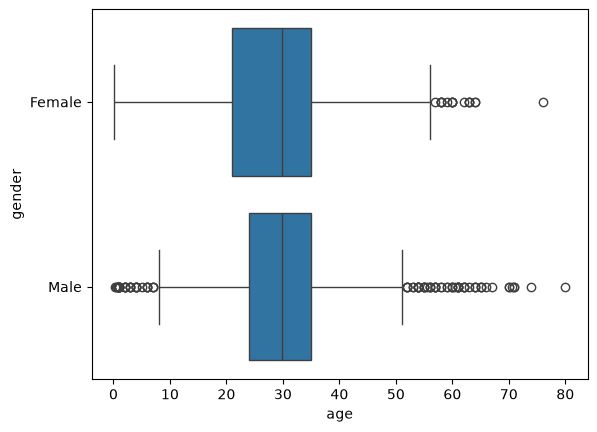

In [59]:
sns.boxplot(df,x='age', y ='gender')

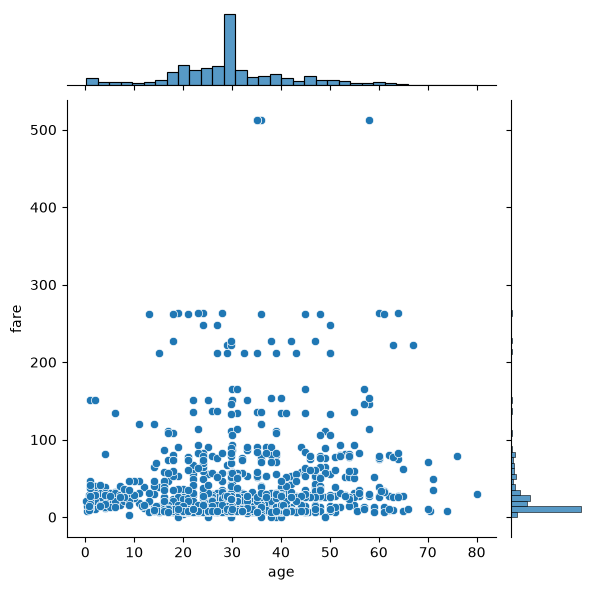

In [60]:
sns.jointplot(df,x='age',y = 'fare')

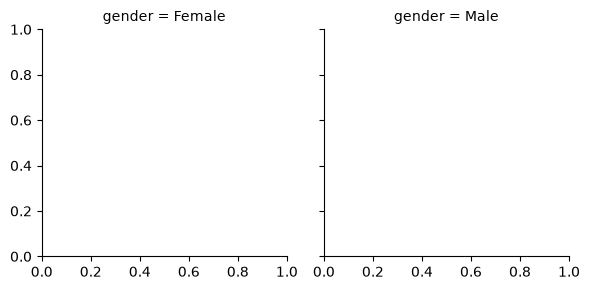

In [ ]:
fg = sns.FacetGrid(df,col='gender')

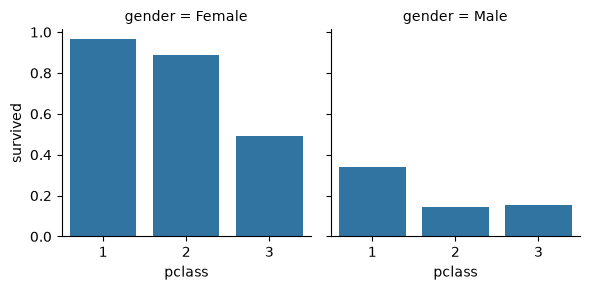

In [71]:
fg = sns.FacetGrid(df,col='gender')
fg.map_dataframe(sns.barplot,x='pclass',y ='survived',estimator='mean',errorbar = None)